In [1]:
import os
import json
import re
import pandas as pd
from utils.utils import process_txt_files, plot_categorical_distribution, get_stat_significance_bootstrap

pd.options.display.max_columns = None

In [2]:
# Použití skriptu
folder_path = "../../data/outputs/fake_news"
df_fake = process_txt_files(folder_path, "fake")

# Zobrazení výsledného dataframe
df_fake

,id,custom_id,News_Source,Article_Tone,Political_Alignment,Subject_Category,Presence_of_Quotes,Number_of_Quotes,Use_of_Statistics,Number_of_Statistics,Article_Length,Presence_of_Images,Number_of_Images,Presence_of_Video,Number_of_Videos,Use_of_Hyperlinks,Number_of_Hyperlinks,Presence_of_Expert_Opinion,Number_of_Expert_Opinions,Presence_of_Emotional_Language,Number_of_Emotional_Expressions,Presence_of_Contradictory_Statements
0,batch_req_67cc6bb226048190839fff12e104c57d,0,Other,Negative,Left,Politics,Yes,6+,No,0,Long,Yes,1-2,No,0,Yes,1-2,No,0,Yes,3-5,No
1,batch_req_67cc6bb236bc8190a20bbafe36150e72,1,Other,Negative,Left,Politics,Yes,1-2,No,0,Long,Yes,1-2,No,0,Yes,1-2,No,0,Yes,3-5,No
2,batch_req_67cc6bb2474481908732dc528308759e,2,Other,Negative,Right,US News,Yes,6+,No,0,Long,Yes,1-2,No,0,Yes,3-5,No,0,Yes,3-5,Yes
3,batch_req_67cc6bb258208190af6cb91ebd53e3fe,3,Other,Negative,Left,Politics,Yes,3-5,Yes,1-2,Long,Yes,1-2,No,0,Yes,3-5,No,0,Yes,3-5,Yes
4,batch_req_67cc6bb267f481909629c57ad2158104,4,Other,Neutral,Left,World News,Yes,3-5,No,0,Long,Yes,1-2,No,0,No,0,No,0,Yes,3-5,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10480,batch_req_67ce515233dc8190af690f7cc240e4d7,10480,Other,Negative,Right,Politics,Yes,3-5,No,0,Medium,No,0,Yes,1-2,Yes,1-2,No,0,Yes,3-5,No
10481,batch_req_67ce51524efc8190a6a2d3ef0b168f8a,10481,Other,Negative,Left,Politics,Yes,1-2,No,0,Medium,No,0,No,0,No,0,No,0,Yes,1-2,No
10482,batch_req_67ce515260d48190b658359035ba173e,10482,CNN,Negative,Left,Politics,Yes,1-2,No,0,Medium,No,0,Yes,1-2,No,0,No,0,Yes,3-5,Yes
10483,batch_req_67ce515271b881909dc508c8a137f7ea,10483,Other,Negative,Right,Politics,Yes,1-2,No,0,Medium,No,0,Yes,1-2,No,0,No,0,Yes,3-5,No


In [3]:
df_fake = df_fake.drop(columns=["id", "custom_id"])

In [4]:
from datasets import load_dataset

data_load = load_dataset("odegiber/")


C:\Users\vojta\Python\anaconda3\envs\ag\lib\site-packages\datasets\load.py:1486: FutureWarning: The repository for odegiber/hate_speech18 contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/odegiber/hate_speech18
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


In [5]:
load_dataset = pd.DataFrame(data_load['train'])
#load_dataset_test = pd.DataFrame(data_load['test'])
#load_dataset = pd.concat([load_dataset, load_dataset_test], axis=0)
df_fake['label'] = list(load_dataset['label'])[:len(df_fake)]

In [6]:

# df_fake = pd.get_dummies(
#     df_fake, sparse=False, prefix_sep='_'
# )

Original P-value: 0.4974361838209057
Bootstrap Mean P-value: 0.07796935441276784
Relationship is significant in 453/2500 bootstrap samples.
Cramér's V (Effect Size): 0.027263559110784524
Effect Size: Weak association
No significant association between News_Source and label.
---------------------------------------------------------------


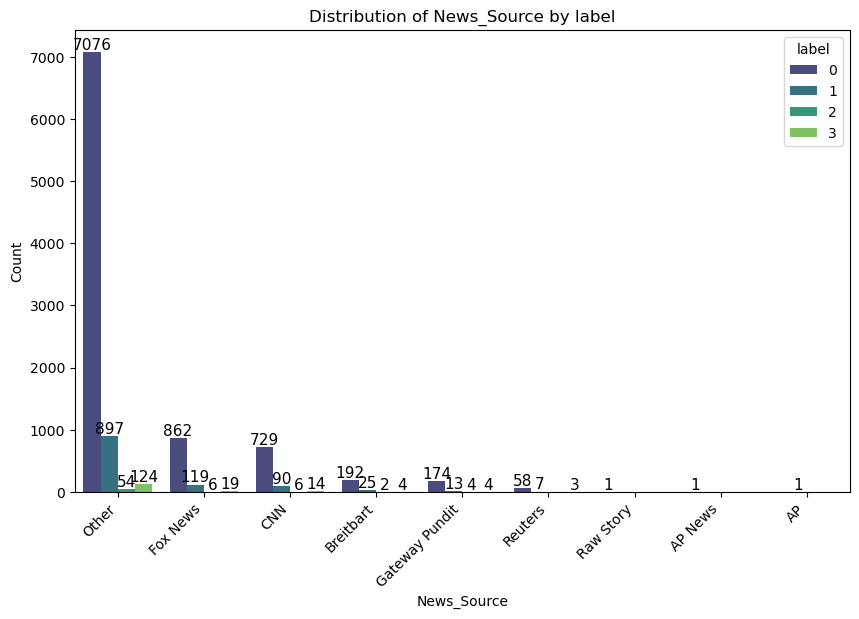

Original P-value: 0.010872418482431624
Bootstrap Mean P-value: 0.02669210680227668
Relationship is significant in 2200/2500 bootstrap samples.
Cramér's V (Effect Size): 0.026101495901326047
Effect Size: Weak association
Significant association between Article_Tone and label.
---------------------------------------------------------------


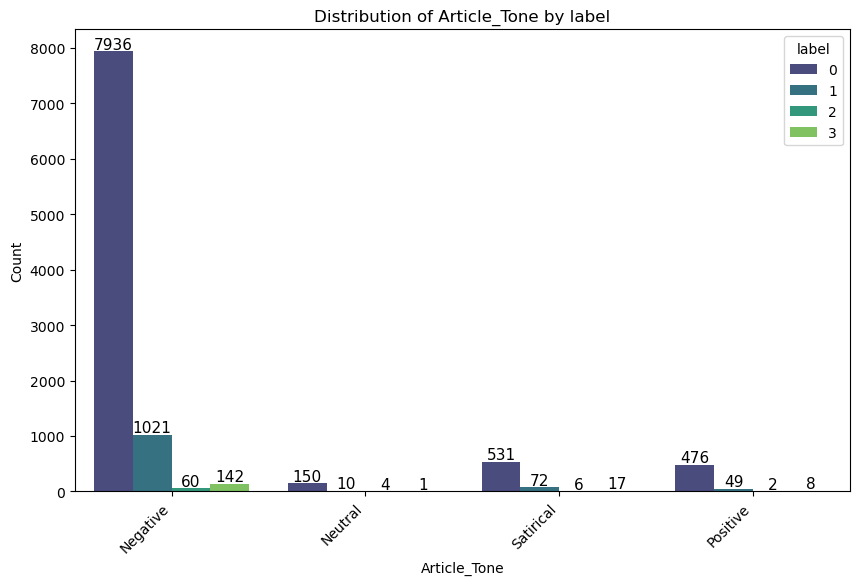

Original P-value: 2.5055852222289145e-07
Bootstrap Mean P-value: 0.003760791821759672
Relationship is significant in 2450/2500 bootstrap samples.
Cramér's V (Effect Size): 0.039082030968291374
Effect Size: Weak association
Significant association between Political_Alignment and label.
---------------------------------------------------------------


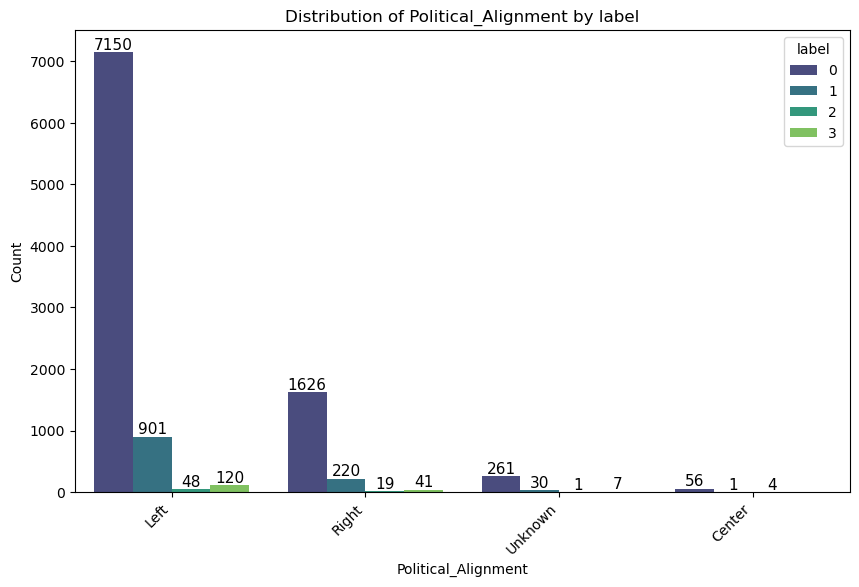

Original P-value: 0.6465179486778776
Bootstrap Mean P-value: 0.23029524450551198
Relationship is significant in 882/2500 bootstrap samples.
Cramér's V (Effect Size): 0.023947743635413483
Effect Size: Weak association
No significant association between Subject_Category and label.
---------------------------------------------------------------


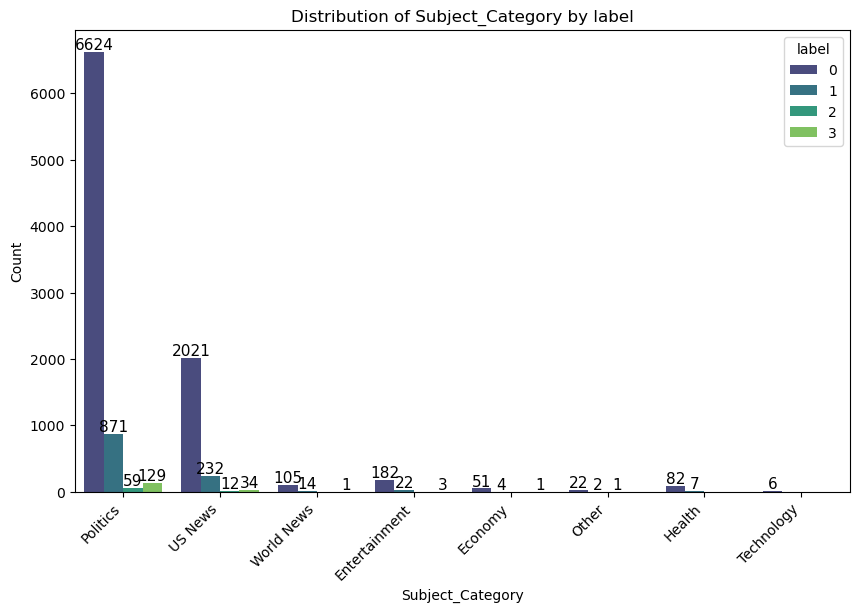

Original P-value: 0.4926356928616821
Bootstrap Mean P-value: 0.2913392523365843
Relationship is significant in 421/2500 bootstrap samples.
Cramér's V (Effect Size): 0.015146307542041772
Effect Size: Weak association
No significant association between Presence_of_Quotes and label.
---------------------------------------------------------------


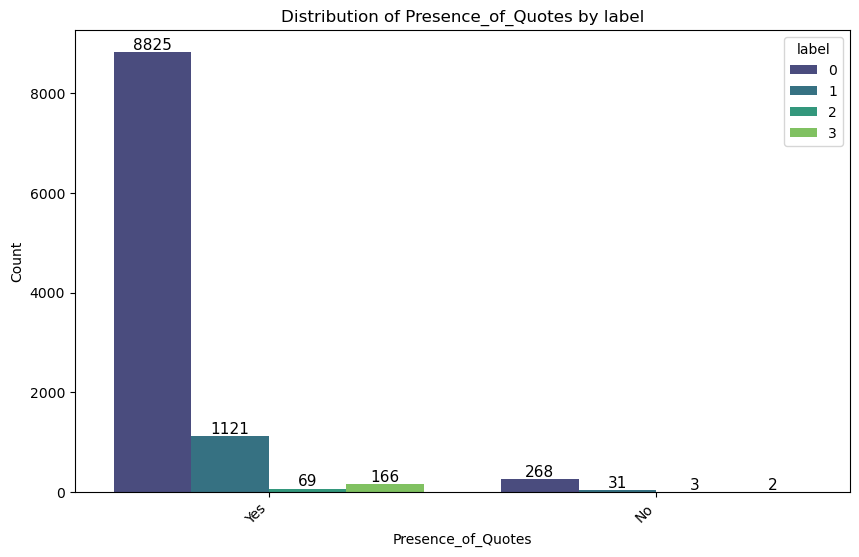

Original P-value: 0.7562458895133047
Bootstrap Mean P-value: 0.23126673330710282
Relationship is significant in 643/2500 bootstrap samples.
Cramér's V (Effect Size): 0.013620733759313757
Effect Size: Weak association
No significant association between Number_of_Quotes and label.
---------------------------------------------------------------


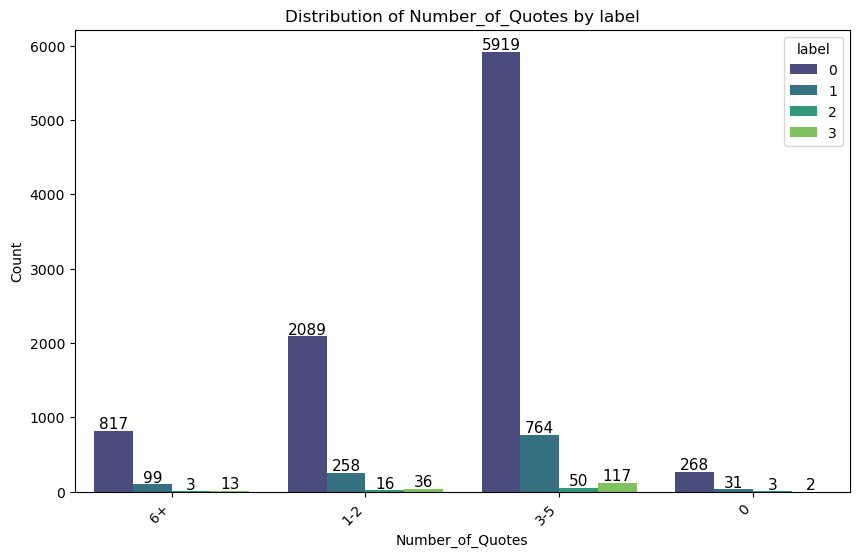

Original P-value: 0.3273781097341958
Bootstrap Mean P-value: 0.24537264102303538
Relationship is significant in 803/2500 bootstrap samples.
Cramér's V (Effect Size): 0.018138046817137973
Effect Size: Weak association
No significant association between Use_of_Statistics and label.
---------------------------------------------------------------


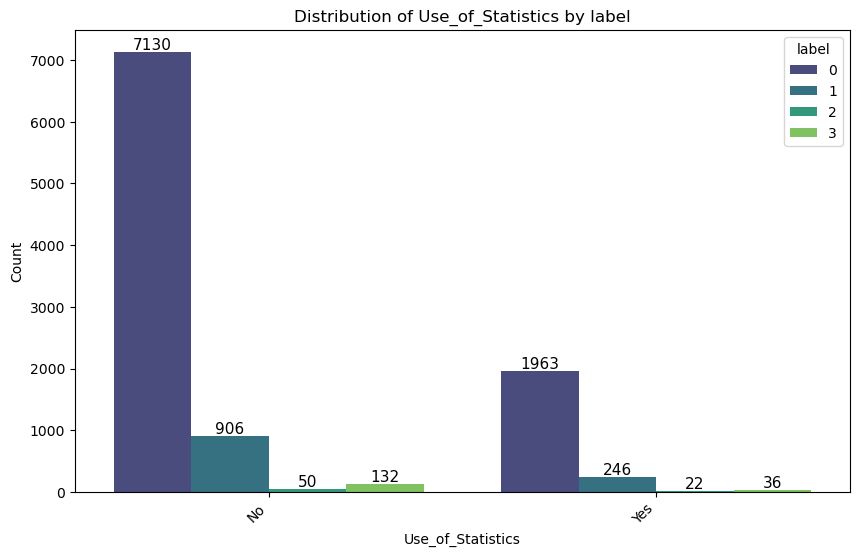

Original P-value: 0.5036715739631583
Bootstrap Mean P-value: 0.1496142367217439
Relationship is significant in 1383/2500 bootstrap samples.
Cramér's V (Effect Size): 0.018951003867039917
Effect Size: Weak association
No significant association between Number_of_Statistics and label.
---------------------------------------------------------------


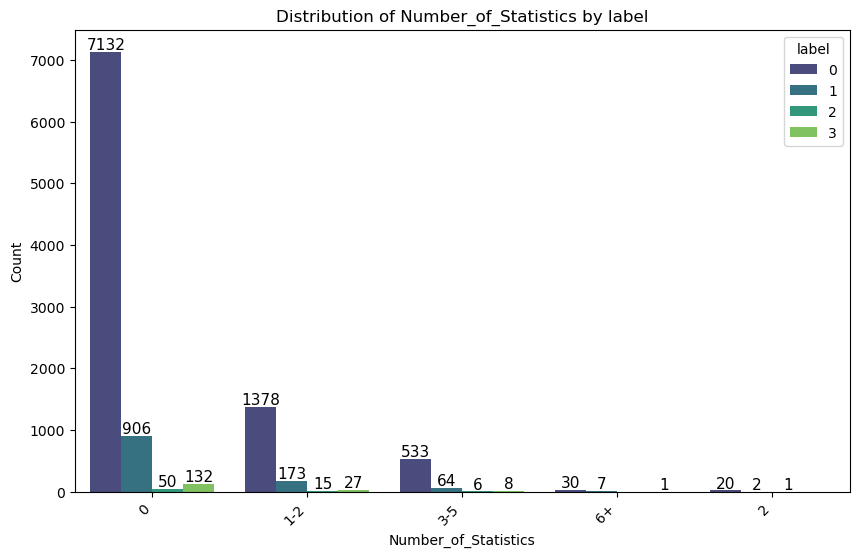

Original P-value: 0.5745523463273201
Bootstrap Mean P-value: 0.37799556412713003
Relationship is significant in 453/2500 bootstrap samples.
Cramér's V (Effect Size): 0.015070931877766517
Effect Size: Weak association
No significant association between Article_Length and label.
---------------------------------------------------------------


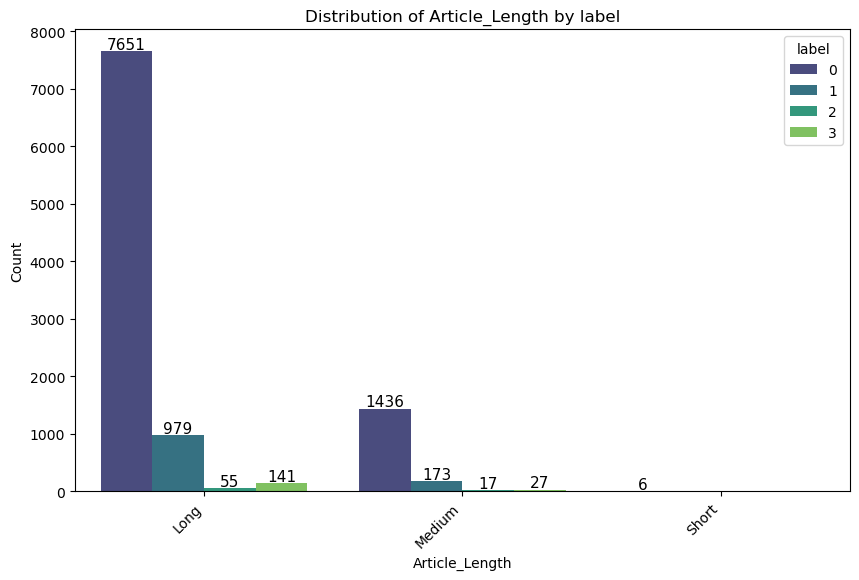

Original P-value: 0.09208908664812858
Bootstrap Mean P-value: 0.13084161362134622
Relationship is significant in 1382/2500 bootstrap samples.
Cramér's V (Effect Size): 0.024781846474311246
Effect Size: Weak association
No significant association between Presence_of_Images and label.
---------------------------------------------------------------


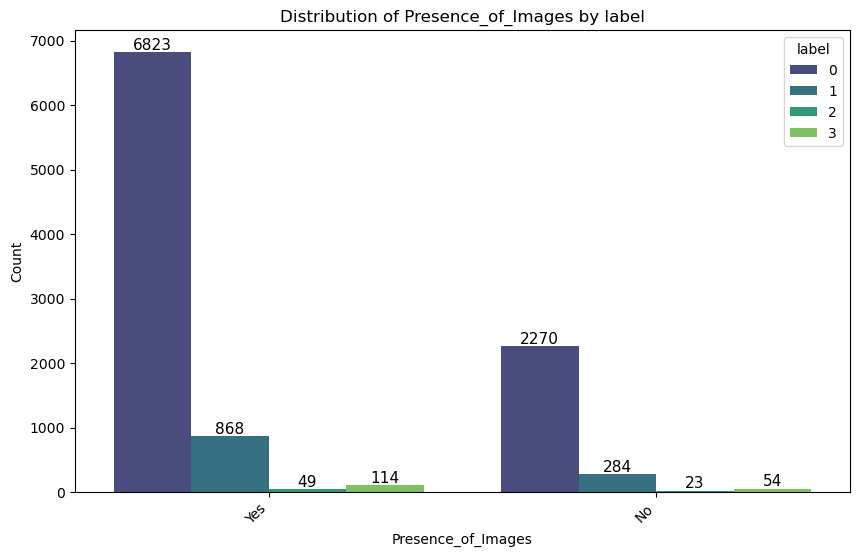

Original P-value: 0.7269891614216248
Bootstrap Mean P-value: 0.16608731794474182
Relationship is significant in 1230/2500 bootstrap samples.
Cramér's V (Effect Size): 0.016646013386095233
Effect Size: Weak association
No significant association between Number_of_Images and label.
---------------------------------------------------------------


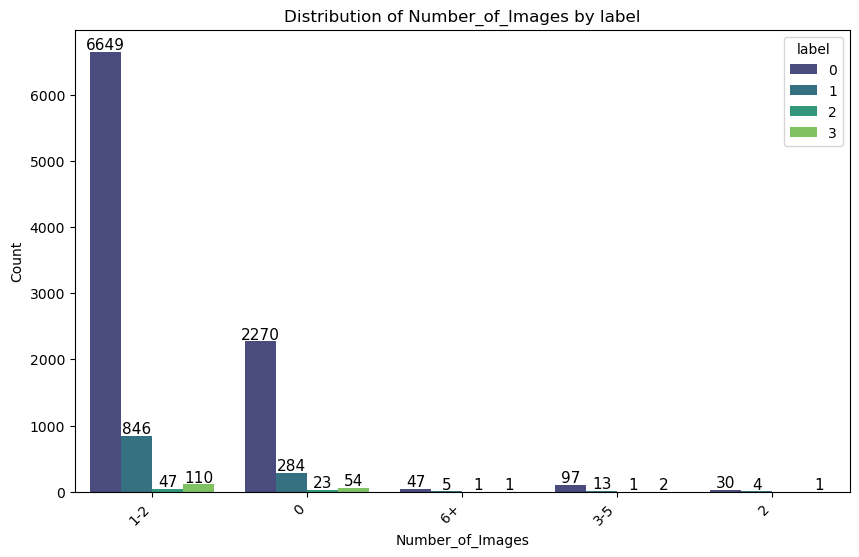

Original P-value: 0.2447589005107535
Bootstrap Mean P-value: 0.19879504353197294
Relationship is significant in 952/2500 bootstrap samples.
Cramér's V (Effect Size): 0.01991731572129968
Effect Size: Weak association
No significant association between Presence_of_Video and label.
---------------------------------------------------------------


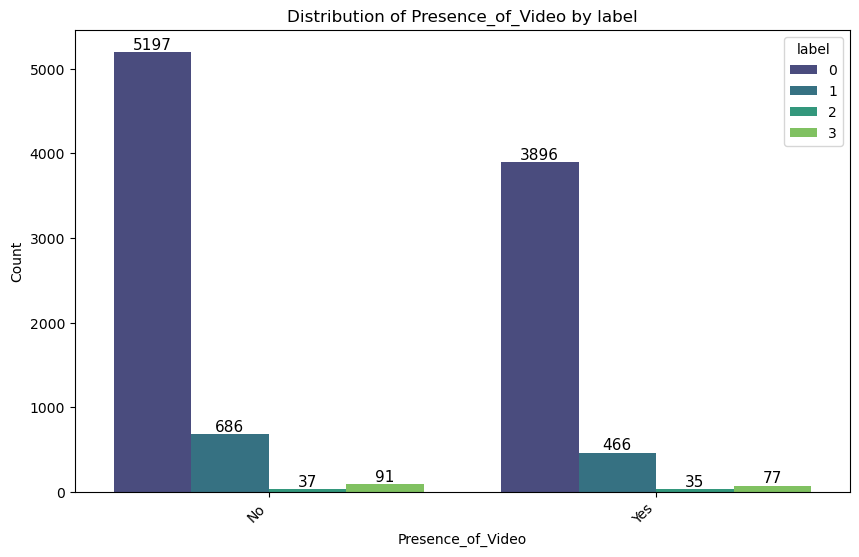

Original P-value: 0.9786764687948813
Bootstrap Mean P-value: 0.6918854570983209
Relationship is significant in 46/2500 bootstrap samples.
Cramér's V (Effect Size): 0.015945102775958574
Effect Size: Weak association
No significant association between Number_of_Videos and label.
---------------------------------------------------------------


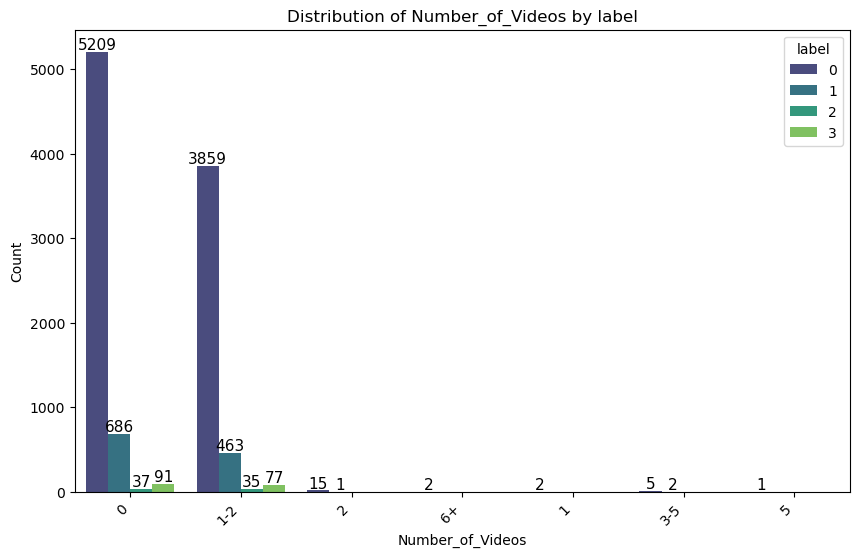

Original P-value: 0.07709971205122312
Bootstrap Mean P-value: 0.10438789950260921
Relationship is significant in 1448/2500 bootstrap samples.
Cramér's V (Effect Size): 0.025545534557180057
Effect Size: Weak association
No significant association between Use_of_Hyperlinks and label.
---------------------------------------------------------------


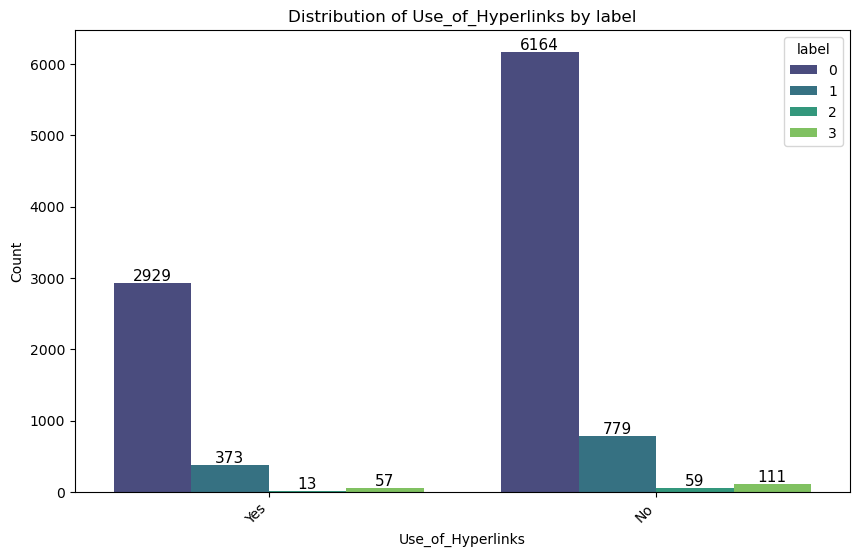

Original P-value: 0.8045069983093165
Bootstrap Mean P-value: 0.2859012799871724
Relationship is significant in 358/2500 bootstrap samples.
Cramér's V (Effect Size): 0.018041100467099072
Effect Size: Weak association
No significant association between Number_of_Hyperlinks and label.
---------------------------------------------------------------


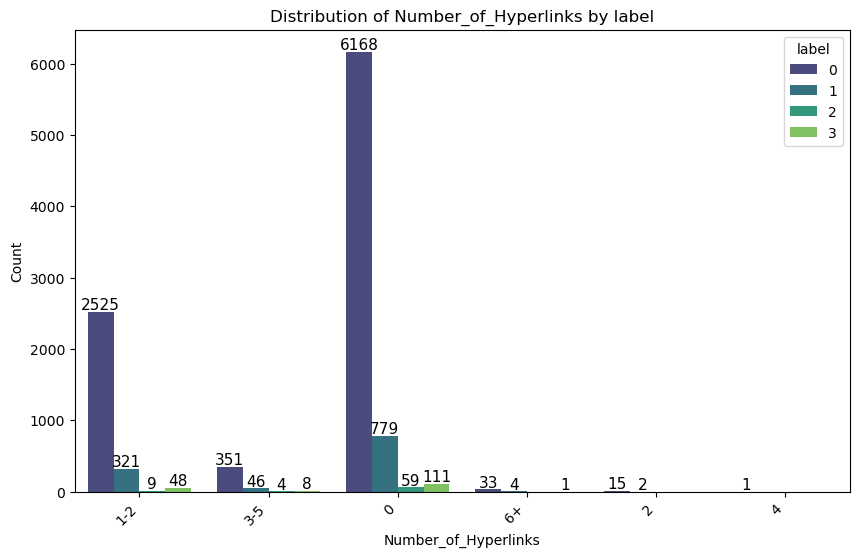

Original P-value: 0.17485770019993999
Bootstrap Mean P-value: 0.16912096287675712
Relationship is significant in 1150/2500 bootstrap samples.
Cramér's V (Effect Size): 0.021746685429819564
Effect Size: Weak association
No significant association between Presence_of_Expert_Opinion and label.
---------------------------------------------------------------


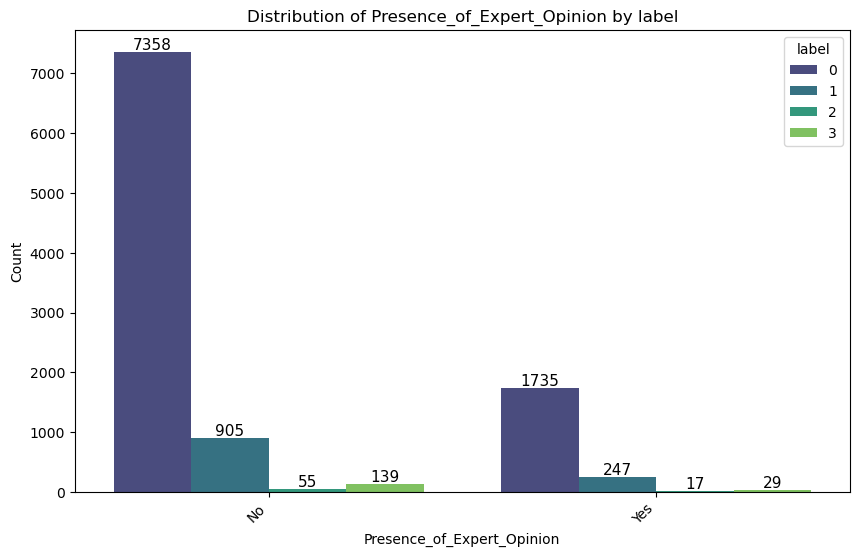

Original P-value: 0.8343558198058662
Bootstrap Mean P-value: 0.4631721478678554
Relationship is significant in 285/2500 bootstrap samples.
Cramér's V (Effect Size): 0.015275710772443113
Effect Size: Weak association
No significant association between Number_of_Expert_Opinions and label.
---------------------------------------------------------------


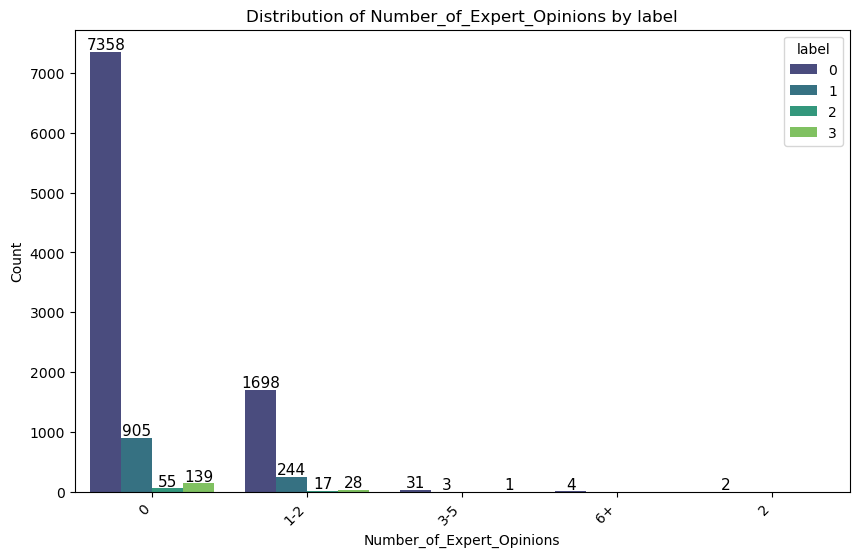

Original P-value: 0.4050928660246347
Bootstrap Mean P-value: 0.4176357999302162
Relationship is significant in 0/2500 bootstrap samples.
Cramér's V (Effect Size): 0.01667064707395811
Effect Size: Weak association
No significant association between Presence_of_Emotional_Language and label.
---------------------------------------------------------------


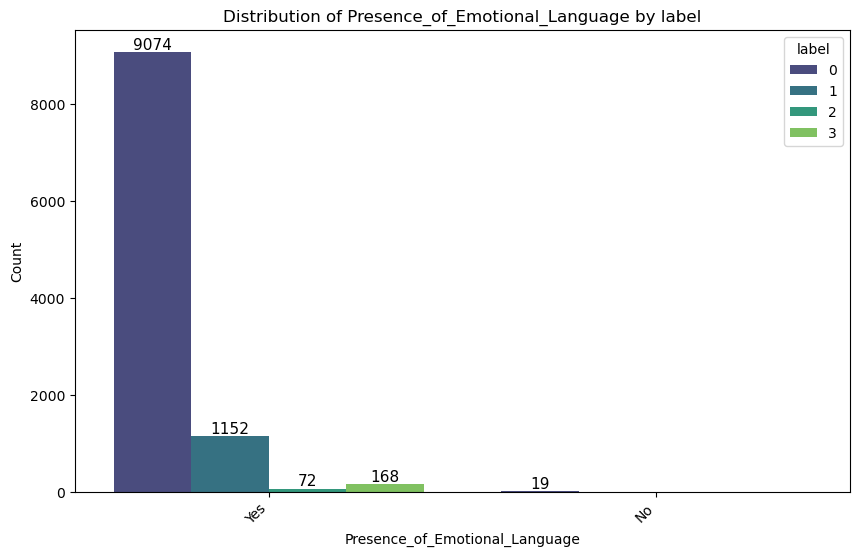

Original P-value: 0.2764888008513189
Bootstrap Mean P-value: 0.18994155976198202
Relationship is significant in 603/2500 bootstrap samples.
Cramér's V (Effect Size): 0.02138889315326513
Effect Size: Weak association
No significant association between Number_of_Emotional_Expressions and label.
---------------------------------------------------------------


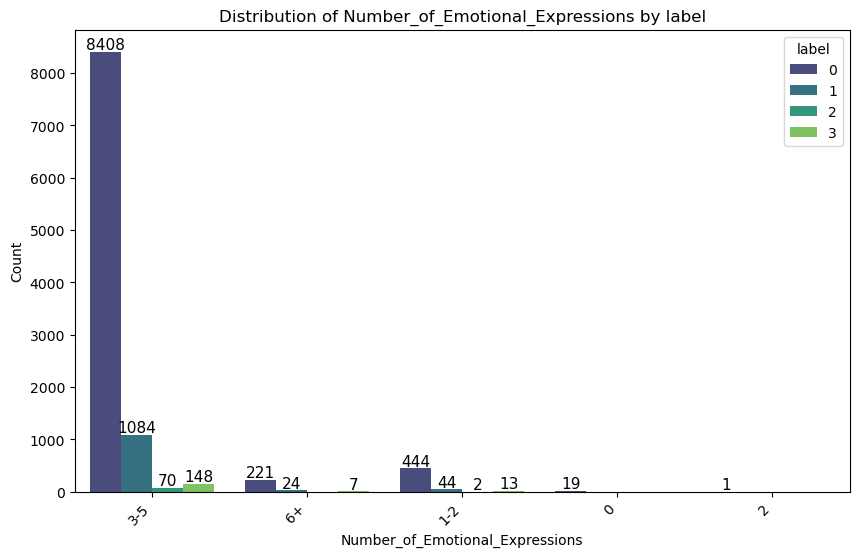

Original P-value: 0.14639236753633958
Bootstrap Mean P-value: 0.15308090545252226
Relationship is significant in 1208/2500 bootstrap samples.
Cramér's V (Effect Size): 0.022638705599337717
Effect Size: Weak association
No significant association between Presence_of_Contradictory_Statements and label.
---------------------------------------------------------------


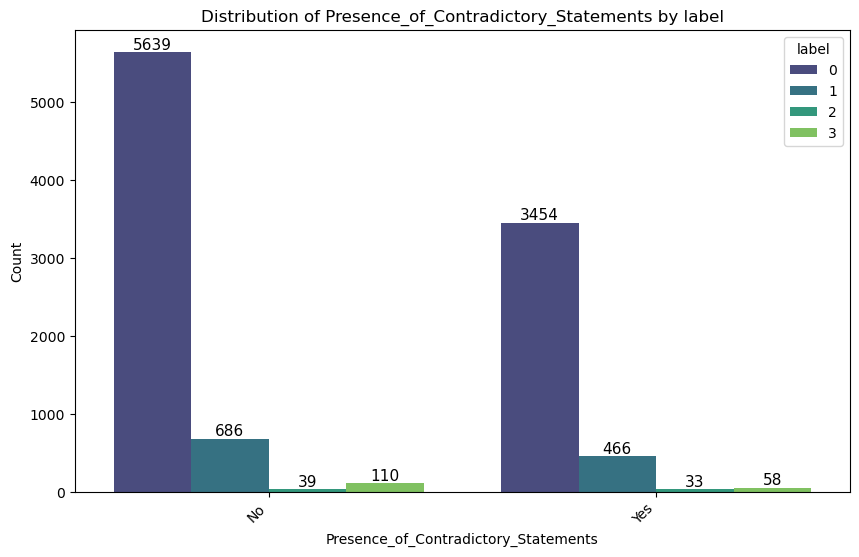

In [7]:
for col in df_fake.drop(columns = ['label']).columns:
    get_stat_significance_bootstrap(df_fake, col, 'label')
    plot_categorical_distribution(df_fake, 'label', col)